# Running parameter estimation

In this short example we'll show how to run parameter estimation with `pyringdown` models using `nessai`. We'll use some mock data for this.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyringdown.inference.likelihood import FDLikelihood
from pyringdown.waveform.interface import FDWaveform, TDWaveform
from pyringdown.waveform.fd import small_angle as fd_small_angle  # for the analysis
from pyringdown.waveform.td import small_angle  # for the injection

from pyringdown.inference.model import NessaiModel
from nessai.flowsampler import FlowSampler
from nessai.utils import configure_logger

import jax
jax.config.update("jax_enable_x64", True)

First, let's make some mock data to fit.

In [2]:
dt = 1e-3  # cadence
T = 2  # duration
sigma = 1e-2 # noise level

wf_td = TDWaveform(small_angle, dt=dt, T=T)

wf_td.parameters

['A', 'gamma', 'f_N', 'phi0']

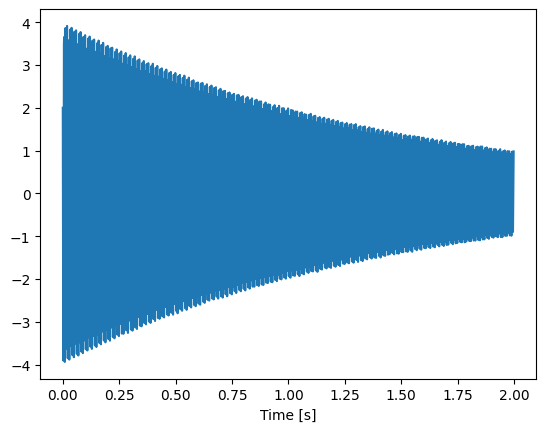

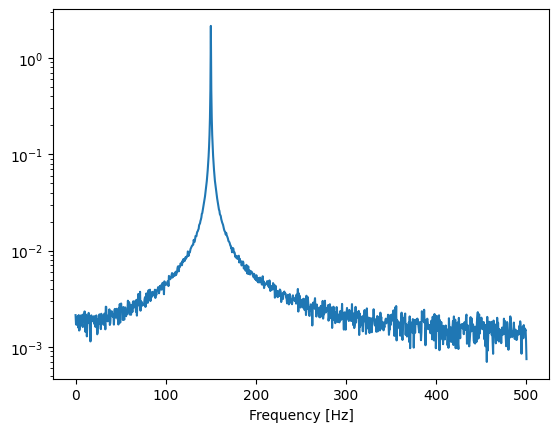

In [16]:

# injection parameters
inj_pars = {
    "A" : 4,
    "gamma" : 0.7,
    "f_N" : 150,
    "phi0" : np.pi/3,
}

signal = wf_td.get_td_waveform(inj_pars)

data = signal + sigma * np.random.normal(size=wf_td.Nt)

plt.plot(wf_td.t, data)
plt.xlabel("Time [s]")
plt.show()

# convert to frequency domain
fr = np.fft.rfftfreq(wf_td.Nt, dt)
data_fd = np.fft.rfft(data) * dt
plt.semilogy(fr, np.abs(data_fd))
plt.xlabel("Frequency [Hz]")
plt.show()

Now, let's set up our analysis waveform and configure `nessai` (see the `nessai` documentation for more help with the latter.). For the frequency domain waveforms, we can set a minimum and maximum frequency to save computational cost.

We must also choose bounds for our analysis.

In [17]:
output = "./outdir/mock-data-example/"
logger = configure_logger(output=output)

wf_fd = FDWaveform(fd_small_angle, dt=dt, T=T, df=1/T, f_min=140, f_max=160)

data = sigma * np.random.normal(size=wf_td.Nt)
data = data + wf_td.get_td_waveform(inj_pars)

fd_like = FDLikelihood(
    wf_fd, 
    td_data=data, 
    estimate_noise=True,
)

bounds = dict(
    A = [3.5, 4.5],
    gamma = [0.5, 0.9],
    f_N = [149.5, 150.5],
    phi0 = [0, 2*np.pi],
    noise_psd = [1e-8, 1e-4]  # noise PSD prior bounds. Check the periodogram for a reasonable guess.
)

model = NessaiModel(fd_like, bounds)


09-28 22:28 nessai INFO    : Running Nessai version 0.15.0


In [18]:
# The FlowSampler object is used to managed the sampling. Keyword arguments
# are passed to the nested sampling.
fs = FlowSampler(model, output=output, resume=False, seed=1729)

# And go!
fs.run()

09-28 22:28 nessai INFO    : pool and n_pool are none, no multiprocessing pool
09-28 22:28 nessai INFO    : Initialising nested sampler
09-28 22:28 nessai WARNING : Multiprocessing pool has already been configured.
09-28 22:28 nessai INFO    : Passing kwargs to FlowProposal: {'poolsize': 2000}
09-28 22:28 nessai INFO    : No reparameterisations provided, using default reparameterisations included in FlowProposal
09-28 22:28 nessai INFO    : Adding reparameterisations from: {}
09-28 22:28 nessai INFO    : Assuming fallback reparameterisation (ScaleAndShift) for ['phi0', 'gamma', 'A', 'noise_psd', 'f_N'] with kwargs: {'estimate_scale': True, 'estimate_shift': True, 'prior_bounds': {'phi0': array([0.        , 6.28318531]), 'gamma': array([0.5, 0.9]), 'A': array([3.5, 4.5]), 'noise_psd': array([1.e-08, 1.e-04]), 'f_N': array([149.5, 150.5])}}.
09-28 22:28 nessai INFO    : x space parameters: ['phi0', 'gamma', 'A', 'noise_psd', 'f_N']
09-28 22:28 nessai INFO    : x prime space parameters: [

In [19]:
from nessai.plot import corner_plot
import os

truths = inj_pars.copy()
truths['noise_psd'] = sigma**2 * dt * 4

corner_plot(
    fs.posterior_samples,
    truths=truths,
    exclude=['logP','logL','it'],  # additional nessai outputs, excluded for corner plot
    filename=os.path.join(output, "corner.pdf")
)

Finally, let's check out the residual compared to the injection:

In [28]:
best_fit_template = wf_td.get_td_waveform(
    {nm: fs.posterior_samples[nm].mean() for nm in wf_td.parameters}
) 
resid = data - best_fit_template

(0.0, 0.5)

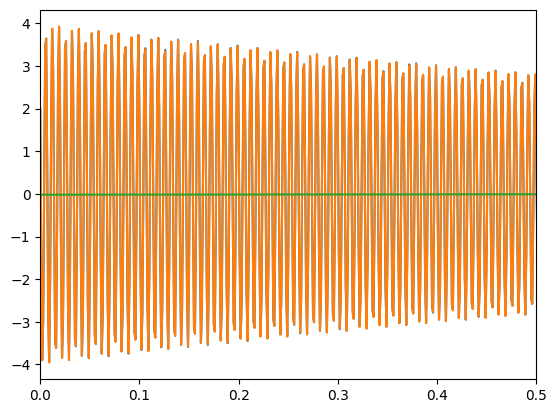

In [34]:
plt.plot(wf_td.t, data)
plt.plot(wf_td.t, best_fit_template)
plt.plot(resid)
plt.xlim(0, 0.5)

From the periodogram, we can see that the residual closely matches the original noise.

(140, 160)

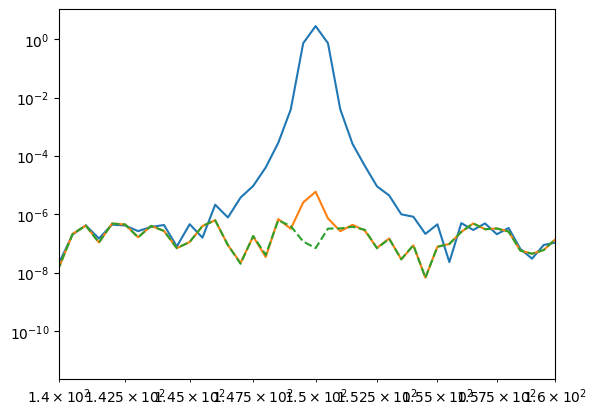

In [36]:
from scipy.signal import welch

welch_out = welch(data, fs=1/dt, nperseg=len(data)//1,)
welch_resid = welch(resid, fs=1/dt, nperseg=len(data)//1,)
welch_noise = welch(data - signal, fs=1/dt, nperseg=len(data)//1,)
plt.loglog(*welch_out)
plt.loglog(*welch_resid)
plt.loglog(*welch_noise, ls='--')
plt.xlim(140, 160)